# Ecological interaction outcome prediction with BacPT

This notebook reproduces the manuscript's ecological-interaction-prediction
pipeline (Methods: *"Ecological interaction prediction pipeline"*, Figure 5):
for a pair of species in a shared environment, build a feature vector from
their BacPT genome-mean embeddings and train a linear probe to predict the
interaction outcome (e.g. mutualism, competition). Two evaluation
strategies are compared, matching the manuscript: a **random** train/test
split over species pairs, and a stricter **species-disjoint** split where
no species in the validation set appears in training.

> **This notebook runs on entirely synthetic data.** The species below are
> randomly generated amino-acid sequences with no biological meaning, and
> the interaction labels are assigned arbitrarily. The resulting F1 scores
> and plots demonstrate that the *pipeline* runs end-to-end — they say
> nothing about real ecological interactions and should not be interpreted
> biologically. To run this on real data, point
> `inference/ecological_interactions.py`'s CLI at your own directory of
> per-species FASTA files and a labels CSV in the same shape
> (`species_a, species_b, environment, label`).

In [1]:
import sys
import itertools
import tempfile
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt

from inference.ecological_interactions import (
    embed_all_species, build_dataset, filter_rare_classes,
    random_split_cv, species_disjoint_cv,
)

## Generate synthetic species and interaction labels

Random amino-acid sequences stand in for genomes (a handful of short genes
each); interaction labels are assigned arbitrarily but kept class-balanced
so the downstream classifiers have something to fit.

In [2]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
N_SPECIES = 8
ENVIRONMENTS = ["DummyCarbonA", "DummyCarbonB"]
CLASSES = ["Mutualism", "Competition", "Neutralism"]
SEED = 0

rng = np.random.default_rng(SEED)
fasta_dir = Path(tempfile.mkdtemp(prefix="bacpt_synthetic_species_"))
species_ids = [f"dummy_sp{i}" for i in range(N_SPECIES)]

for sid in species_ids:
    n_genes = rng.integers(5, 9)
    records = []
    for g in range(n_genes):
        length = rng.integers(80, 200)
        seq = "".join(rng.choice(list(AMINO_ACIDS), size=length))
        records.append(f">{sid}_gene{g}\n{seq}")
    (fasta_dir / f"{sid}.faa").write_text("\n".join(records) + "\n")

rows = []
for a, b in itertools.combinations(species_ids, 2):
    for env in ENVIRONMENTS:
        label = CLASSES[hash((a, b, env)) % len(CLASSES)]
        rows.append({"species_a": a, "species_b": b, "environment": env, "label": label})
pairs_df = pd.DataFrame(rows)

print(f"{N_SPECIES} synthetic species, {len(pairs_df)} pairwise samples across {len(ENVIRONMENTS)} environments")
print(pairs_df["label"].value_counts())

8 synthetic species, 56 pairwise samples across 2 environments
label
Competition    21
Neutralism     19
Mutualism      16
Name: count, dtype: int64


## Embed all species

Generates raw ESM2 embeddings and contextualized BacPT-small/BacPT-large
embeddings (all layers, mean-pooled per genome) for every synthetic
species. `load_bacpt_release` downloads the public Hugging Face weights;
the normalization scaler reuses the already-bundled
`data/ecoli_k12/scaler.npz` (a generic fitted BacPT input scaler).

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SCALER_PATH = REPO_ROOT / "data" / "ecoli_k12" / "scaler.npz"
embeddings = embed_all_species(fasta_dir, SCALER_PATH, device=device)
print("Embedded species:", list(embeddings.keys()))
print("BacPT-large layers:", embeddings[species_ids[0]]["large"].shape[0])
print("BacPT-small layers:", embeddings[species_ids[0]]["small"].shape[0])

Using device: cuda


Embedded species: ['dummy_sp0', 'dummy_sp1', 'dummy_sp2', 'dummy_sp3', 'dummy_sp4', 'dummy_sp5', 'dummy_sp6', 'dummy_sp7']
BacPT-large layers: 20
BacPT-small layers: 11


## Run the interaction-prediction sweep

For each model (ESM baseline, BacPT-small, BacPT-large), environment, and
layer, trains a linear probe and records macro-F1, averaged over a few
seeds. The expensive step (embedding each species) already happened once
above — everything here just slices the cached embeddings, so sweeping the
full grid is cheap even though it mirrors the manuscript's full
methodology.

In [4]:
SEEDS = [42, 7, 123]
MIN_CLASS_COUNT = 3
NUM_LAYERS = {"esm": 1, "small": embeddings[species_ids[0]]["small"].shape[0],
              "large": embeddings[species_ids[0]]["large"].shape[0]}

def run_sweep(cv_fn, species_disjoint):
    env_vs_f1 = {seed: {"esm": {}, "small": {}, "large": {}} for seed in SEEDS}
    for seed in SEEDS:
        for model_key in ("esm", "small", "large"):
            for layer in range(NUM_LAYERS[model_key]):
                for env in ENVIRONMENTS:
                    X, y, species_pairs = build_dataset(pairs_df, embeddings, model_key, layer, env)
                    X, y, species_pairs = filter_rare_classes(X, y, species_pairs, MIN_CLASS_COUNT)
                    if len(set(y.tolist())) < 2:
                        continue
                    try:
                        f1 = (cv_fn(X, species_pairs, y, seed=seed)["F1"] if species_disjoint
                              else cv_fn(X, y, seed=seed)["F1"])
                    except (ValueError, RuntimeError):
                        continue
                    env_vs_f1[seed][model_key].setdefault(env, {})[layer] = f1
    return env_vs_f1

def summarize(env_vs_f1):
    rows = []
    for model_key in ("esm", "small", "large"):
        for env in ENVIRONMENTS:
            per_seed_best = []
            for seed in SEEDS:
                layer_dict = env_vs_f1[seed][model_key].get(env, {})
                if layer_dict:
                    per_seed_best.append(max(layer_dict.values()))
            if per_seed_best:
                rows.append([model_key, env, np.mean(per_seed_best), np.std(per_seed_best)])
    return pd.DataFrame(rows, columns=["Model", "Environment", "Mean_F1", "Std_F1"])

df_random = summarize(run_sweep(random_split_cv, species_disjoint=False))
df_disjoint = summarize(run_sweep(species_disjoint_cv, species_disjoint=True))
print(df_random)

   Model   Environment   Mean_F1    Std_F1
0    esm  DummyCarbonA  0.294180  0.065132
1    esm  DummyCarbonB  0.305397  0.037164
2  small  DummyCarbonA  0.350370  0.071764
3  small  DummyCarbonB  0.273333  0.011037
4  large  DummyCarbonA  0.330370  0.033767
5  large  DummyCarbonB  0.264444  0.030198


## Model comparison across environments

Grouped bar chart of F1 by environment, colored by model. Since the
underlying data is synthetic and random, there is no reason to expect
BacPT to outperform the raw ESM baseline here — unlike the Jacobian and
scaffolding demos, this one isn't expected to reproduce the paper's
reported direction.

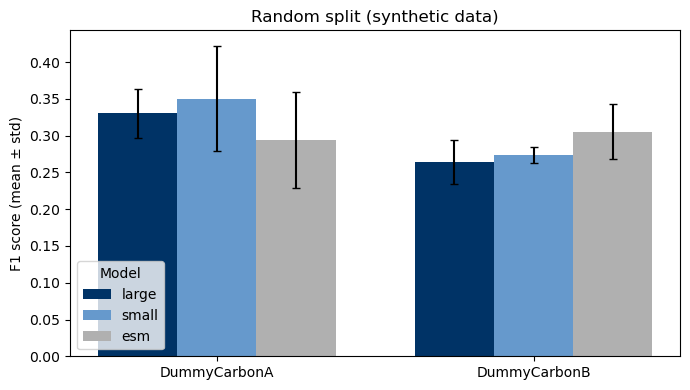

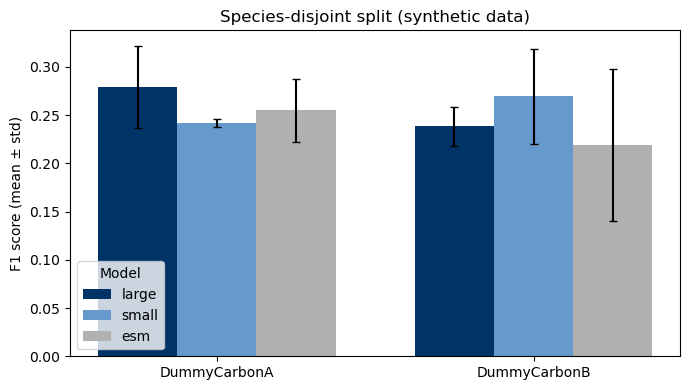

In [5]:
def plot_model_comparison(df_summary, title):
    model_order = ["large", "small", "esm"]
    colors = {"large": "#003366", "small": "#6699CC", "esm": "#B0B0B0"}
    envs = df_summary["Environment"].unique()
    x = np.arange(len(envs))
    width = 0.25

    fig, ax = plt.subplots(figsize=(7, 4))
    for i, model_key in enumerate(model_order):
        sub = df_summary[df_summary["Model"] == model_key].set_index("Environment").reindex(envs)
        ax.bar(x + (i - 1) * width, sub["Mean_F1"], width, yerr=sub["Std_F1"],
               label=model_key, color=colors[model_key], capsize=3)
    ax.set_xticks(x, envs)
    ax.set_ylabel("F1 score (mean ± std)")
    ax.set_title(title)
    ax.legend(title="Model")
    plt.tight_layout()
    plt.show()

plot_model_comparison(df_random, "Random split (synthetic data)")
plot_model_comparison(df_disjoint, "Species-disjoint split (synthetic data)")

## BacPT-large vs. ESM, per environment (random split)

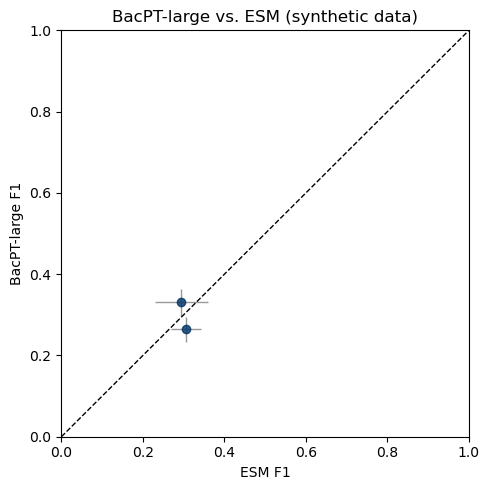

In [6]:
pivot = df_random[df_random["Model"].isin(["large", "esm"])].pivot(
    index="Environment", columns="Model", values=["Mean_F1", "Std_F1"]
).dropna()

fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(pivot["Mean_F1"]["esm"], pivot["Mean_F1"]["large"],
            xerr=pivot["Std_F1"]["esm"], yerr=pivot["Std_F1"]["large"],
            fmt="o", ecolor="gray", capsize=0, elinewidth=1, alpha=0.8, color="#003366")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("ESM F1")
ax.set_ylabel("BacPT-large F1")
ax.set_title("BacPT-large vs. ESM (synthetic data)")
plt.tight_layout()
plt.show()